<a href="https://colab.research.google.com/github/shivanshsingh-123/CODSOFT-INTERNSHIP/blob/main/salesprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Prediction Using Machine Learning

This project predicts product sales based on advertising expenditure across TV, Radio, and Newspaper using Machine Learning regression models.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
print("Rows", df.shape[0])
print("Columns", df.shape[1])

Rows 200
Columns 4


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
print("Duplicate", df.duplicated().sum())

Duplicate 0


## Exploratory Data Analysis (EDA)

Before building the regression models, the dataset was explored to understand its structure and quality.

The following checks were performed:

- Loaded the dataset.
- Displayed the first few records.
- Verified the number of rows and columns.
- Checked data types.
- Checked for missing values.
- Generated descriptive statistics.
- Checked for duplicate records.

EDA helps identify potential data quality issues before model training.

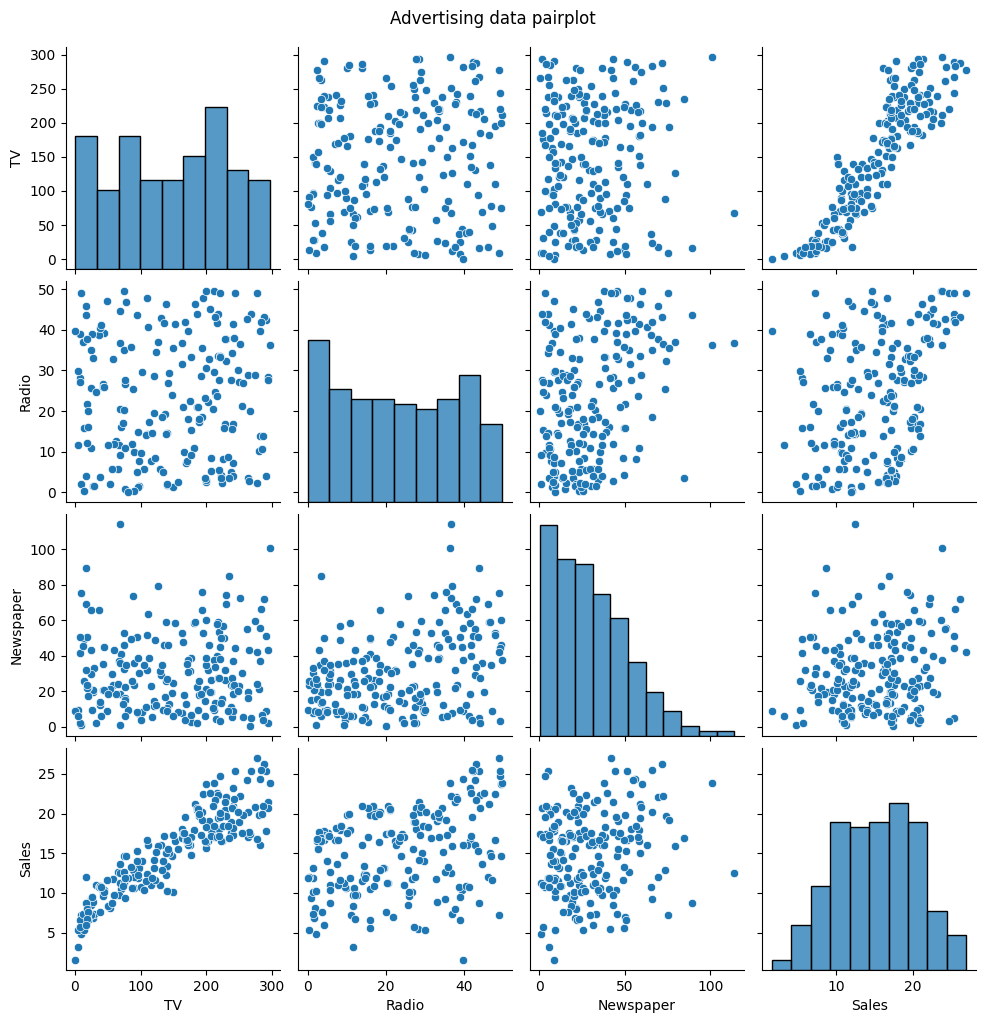

In [ ]:
sns.pairplot(df)
plt.suptitle('Advertising data pairplot', y =1.02)
plt.show()

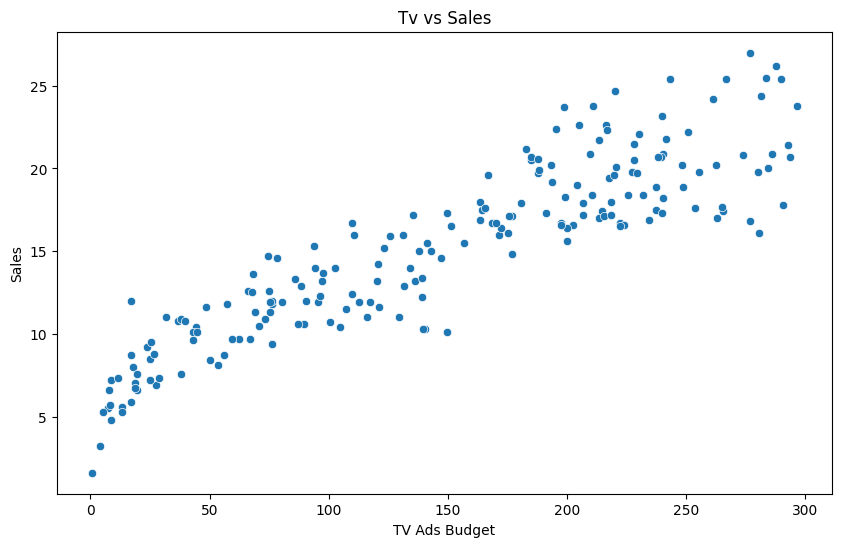

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="TV", y="Sales", data =df)
plt.title("Tv vs Sales")
plt.xlabel("TV Ads Budget")
plt.ylabel("Sales")
plt.show()

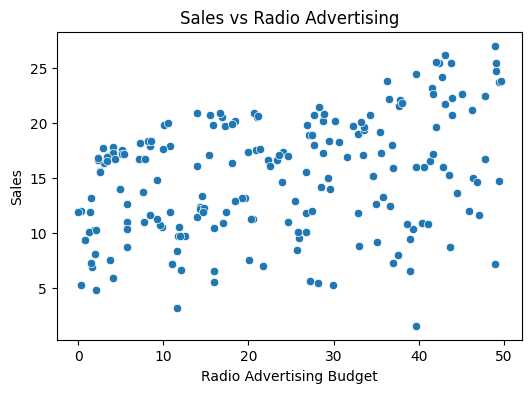

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Radio", y="Sales", data=df)

plt.title("Sales vs Radio Advertising")

plt.xlabel("Radio Advertising Budget")

plt.ylabel("Sales")

plt.show()

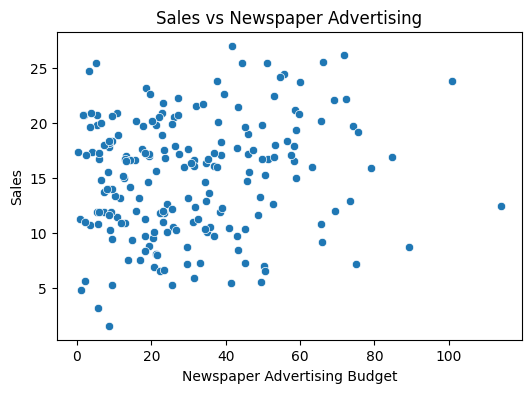

In [ ]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Newspaper", y="Sales", data=df)

plt.title("Sales vs Newspaper Advertising")

plt.xlabel("Newspaper Advertising Budget")

plt.ylabel("Sales")

plt.show()

In [ ]:
corr = df.corr()
corr

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


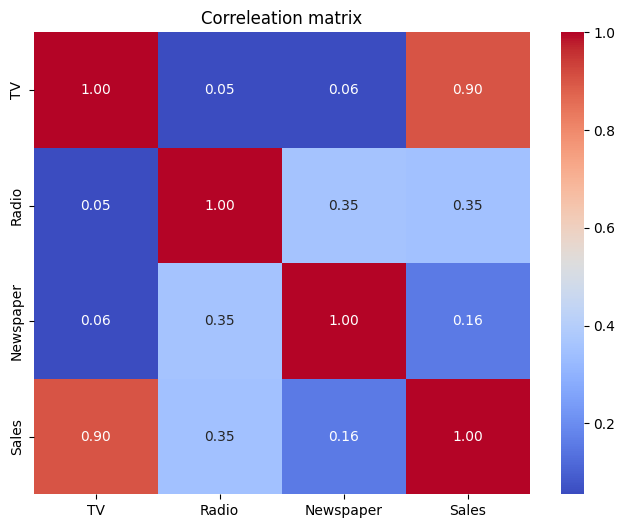

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot = True, cmap='coolwarm', fmt = ".2f")
plt.title("Correleation matrix")
plt.show()

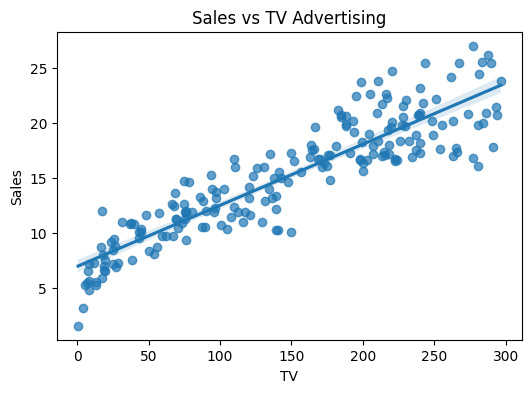

In [ ]:
plt.figure(figsize=(6,4))
sns.regplot(x="TV", y="Sales", data=df, scatter_kws={"alpha":0.7})
plt.title("Sales vs TV Advertising")
plt.show()

In [ ]:
X = df[["TV", "Radio", "Newspaper"]]

In [ ]:
y = df["Sales"]

In [ ]:
print(X.head())

print()

print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_lr
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
comparison_rf = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

comparison_rf.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.299
1,22.4,22.482
2,21.4,19.770
3,7.3,6.784
4,24.7,22.961
5,12.6,13.471
6,22.3,22.595
7,8.4,9.579
8,16.5,16.887
9,16.1,16.793


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
import numpy as np

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("="*50)
    print(model_name)
    print("="*50)

    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R² Score : {r2:.3f}")

    return mae, rmse, r2

In [ ]:
lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_lr
)

Linear Regression
MAE  : 1.275
RMSE : 1.705
R² Score : 0.906


In [ ]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
MAE  : 0.918
RMSE : 1.199
R² Score : 0.953


In [ ]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "MAE":[lr_results[0], rf_results[0]],
    "RMSE":[lr_results[1], rf_results[1]],
    "R² Score":[lr_results[2], rf_results[2]]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.274826,1.705215,0.905901
1,Random Forest,0.918000,1.198930,0.953483


In [ ]:
best_model = rf_model
best_predictions = y_pred_rf

In [ ]:
residuals = y_test - best_predictions

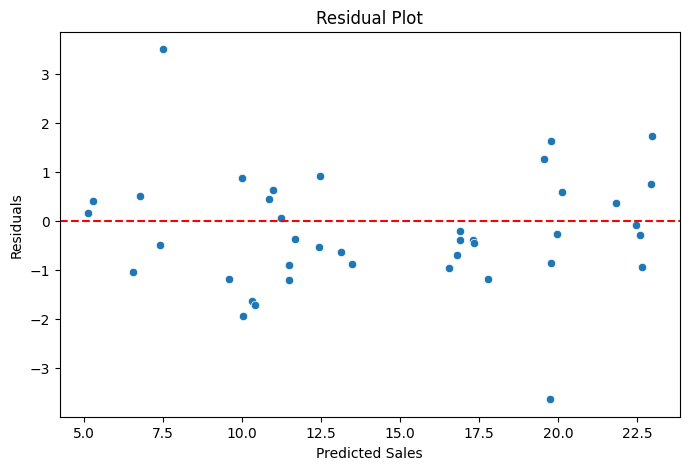

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TV,0.845355
1,Radio,0.136642
2,Newspaper,0.018003


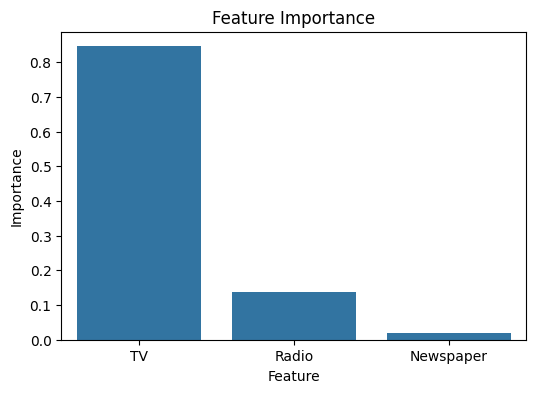

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Feature",
    y="Importance",
    data=importance
)

plt.title("Feature Importance")

plt.show()